In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import json

from pathlib import Path

In [4]:
# Paths
data_path = Path.cwd().parent / 'Data'

In [5]:
dna_json = data_path / 'dnas.json'


In [6]:
with open(dna_json) as f:
    dnas = json.load(f)

print('Number of DNA files:', len(dnas))

Number of DNA files: 622


## DNA Structure
- id: unique identifier
- set: part of which collection (folder)
- type: type of DNA (Drumbeats, RhythmGuitars, SoloGuitars, Empty) **(irrelevant)**
- authorData: author information
- StyleTags: keywords describing dna
- originalMidifileReference: path to original midi file **(irrelevant)**
- AudioFiles: in case of non midi **(irrelevant)**
- IsTimeBased: relevant for audio files **(irrelevant)**
- Bpm: beats per minute
- BpmRangeStart: start of bpm range where this pattern would still make sense (20% slower) -> number was arbitrarily chosen
- BpmRangeEnd: end of bpm range where this pattern would still make sense (20% faster) -> number was arbitrarily chosen
- GridResolution: musical grid resolution e.g. 16th, 8th, 4th notes used to quantize the midi file (Enum value)
- GridFactor: subdivision of the grid resolution based on quarter notes e.g. 8th resolution = 2, 16th resolution = 4, 16-triplet = 6,...
- UnitLengthMs: 1.0 * 60000 / (Bpm * GridFactor)
- BasicKey: key of the midi file **(irrelevant)**
- BasicScale: scale of the midi file **(irrelevant)**
- Numerator: numerator of the time signature
- Denominator: denominator of the time signature
- TicksPerQuarterNote: number of ticks per quarter note
- IsTernary: triplet grid active
- NumberOfBars: number of bars in the midi file
- TicksPerGridUnit: number of ticks per grid unit
- Description: description of the midi file
- FillStartTicks: start ticks where the fill starts
- DNAUnits: list of DNA units
- MusicEvents: Midi representation of the midi file

DNAUnit:

    public class DNAUnit
    {
        public int Value { get; set; } = 0;
        public int? ExcludeValue { get; set; } = null;
        public bool Wildcard { get; set; } = false;

        public int AvgOffsetTicks { get; set; } = 0;
        public int TransposeInstruction { get; set; } = 0;
        public double AvgVelocity { get; set; } = 1.0;

        public Dictionary<int, int> OffsetTicksPerValuePart { get; set; } = new Dictionary<int, int>();
        public Dictionary<int, double> VelocityPerValuePart { get; set; } = new Dictionary<int, double>();

        public bool IsEmpty { get; set; } = false;
        public bool ContinuingLastUnit { get; set; } = false;


    }

In [7]:
dna1 = dnas[0]

for unit in dna1['DNAUnits']:
    if unit['IsEmpty'] == False:
        print(unit['OffsetTicksPerValuePart'])

{'2': 0}
{'2': 0}
{'1': 0}
{'1': 41}
{'1': 6}
{'4': 48, '1': -42}
{'2': 2}
{'2': 1}
{'1': -2}
{'1': 39}
{'1': 4}
{'4': 46, '1': -44}
{'2': -2}
{'1': 1, '32': 1}
{'4': 2}
{'4': 38, '1': -42}
{'1': 2}
{'1': 2}
{'2': 7}
{'1': -5}
{'4': -1}
{'1': 8}


In [8]:
for dna in dnas:
    for unit in dna['DNAUnits']:
        if unit['ContinuingLastUnit'] == True:
            print('Used')
            break

In [9]:

for unit in dna1['DNAUnits']:
    print(unit['VelocityPerValuePart'])

{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{'2': 1}
{'2': 1}
{'1': 1}
{'1': 1}
{'1': 1}
{'4': 1, '1': 1}
{'2': 1}
{'2': 0.9763779527559056}
{'1': 1}
{'1': 1}
{'1': 1}
{'4': 1, '1': 1}
{'2': 1}
{}
{}
{}
{'1': 1, '32': 1}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{'4': 1}
{'4': 0.937007874015748, '1': 0.905511811023622}
{'1': 1}
{}
{'1': 1}
{}
{'2': 1}
{}
{'1': 1}
{}
{'4': 1}
{}
{'1': 1}


In [10]:
for unit in dna1['DNAUnits']:
    print(bin(unit['Value']))

0b0
0b0
0b0
0b0
0b0
0b0
0b0
0b0
0b0
0b0
0b0
0b0
0b0
0b0
0b0
0b0
0b10
0b10
0b1
0b1
0b1
0b101
0b10
0b10
0b1
0b1
0b1
0b101
0b10
0b0
0b0
0b0
0b100001
0b0
0b0
0b0
0b0
0b0
0b0
0b0
0b0
0b0
0b0
0b0
0b0
0b0
0b0
0b0
0b0
0b0
0b100
0b101
0b1
0b0
0b1
0b0
0b10
0b0
0b1
0b0
0b100
0b0
0b1


In [11]:
instrumentValues = {'None': 0, 'Kick' : 1 << 0, 'Snare' : 1 << 1,'Toms' : 1 << 2, 'HHClose': 1 << 3, 'HHOpen' : 1 << 4, 'Ride' : 1 << 5, 'Cymbal' : 1 << 6}
# switch keys and values\
instrumentValues = {v: k for k, v in instrumentValues.items()}
instrumentValues

{0: 'None',
 1: 'Kick',
 2: 'Snare',
 4: 'Toms',
 8: 'HHClose',
 16: 'HHOpen',
 32: 'Ride',
 64: 'Cymbal'}

In [12]:

with open('C:/Users/minem/Desktop/test/dnas_638811080997960799.json') as f:
    test = json.load(f)

print(test[0]['OriginalMidiFileReference'])

for dnaUnit in test[0]['DNAUnits']:
    print(dnaUnit['Value'])
    print(instrumentValues[dnaUnit['Value']])
    print(bin(dnaUnit['Value']))
    print('---')

C:\Users\minem\Desktop\test\allInstruments.mid
8
HHClose
0b1000
---
0
None
0b0
---
8
HHClose
0b1000
---
0
None
0b0
---
8
HHClose
0b1000
---
0
None
0b0
---
8
HHClose
0b1000
---
0
None
0b0
---
8
HHClose
0b1000
---
0
None
0b0
---
8
HHClose
0b1000
---
0
None
0b0
---
1
Kick
0b1
---
0
None
0b0
---
1
Kick
0b1
---
0
None
0b0
---
1
Kick
0b1
---
0
None
0b0
---
1
Kick
0b1
---
0
None
0b0
---
2
Snare
0b10
---
0
None
0b0
---
2
Snare
0b10
---
0
None
0b0
---
2
Snare
0b10
---
0
None
0b0
---
2
Snare
0b10
---
0
None
0b0
---
2
Snare
0b10
---
0
None
0b0
---
2
Snare
0b10
---
0
None
0b0
---
2
Snare
0b10
---
0
None
0b0
---
2
Snare
0b10
---
0
None
0b0
---
2
Snare
0b10
---
0
None
0b0
---
2
Snare
0b10
---
0
None
0b0
---
2
Snare
0b10
---
0
None
0b0
---
2
Snare
0b10
---
0
None
0b0
---
4
Toms
0b100
---
0
None
0b0
---
4
Toms
0b100
---
0
None
0b0
---
4
Toms
0b100
---
0
None
0b0
---
4
Toms
0b100
---
0
None
0b0
---
0
None
0b0
---
0
None
0b0
---
4
Toms
0b100
---
0
None
0b0
---
4
Toms
0b100
---
0
None
0b0
---
4
Toms
0b10

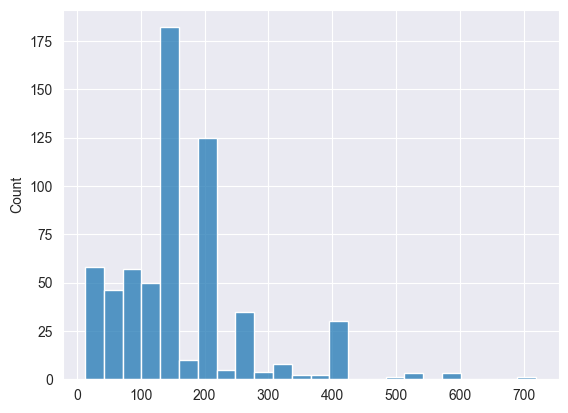

162.54823151125402
102.62387270652
143.0
719
13
87


In [43]:
import numpy as np

dna_unit_lengths = np.zeros((len(dnas)), dtype=int)

for i, dna in enumerate(dnas):
    dna_unit_lengths[i] = len(dna['DNAUnits'])

count_greater = [i for i in dna_unit_lengths if i > 256]

sns.histplot(dna_unit_lengths)
plt.show()
print(np.mean(dna_unit_lengths))
print(np.std(dna_unit_lengths))
print(np.median(dna_unit_lengths))
print(np.max(dna_unit_lengths))
print(np.min(dna_unit_lengths))
print(len(count_greater))
